In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# bitly data

## count by our function

In [9]:
import json
with open('data.txt',encoding='utf-8') as f:
    records=[json.loads(line) for line in f]
df=pd.DataFrame(records)
df

,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1.0,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1.331923e+09,1.331823e+09,Danvers,"[42.576698, -70.954903]",NaN,NaN
1,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331923e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1.331923e+09,1.331920e+09,Washington,"[38.9007, -77.043098]",NaN,NaN
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0.0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,Braz,"[-23.549999, -46.616699]",NaN,NaN
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273672e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3555,Mozilla/4.0 (compatible; MSIE 9.0; Windows NT ...,US,1.0,America/New_York,NJ,e5SvKE,fqPSr9,tweetdeckapi,en,1.usa.gov,direct,http://www.fda.gov/AdvisoryCommittees/Committe...,1.331927e+09,1.301298e+09,Paramus,"[40.9445, -74.07]",NaN,NaN
3556,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/535.1...,US,0.0,America/Chicago,OK,jQLtP4,jQLtP4,bitly,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l.php?u=http%3A%2F%2F1...,http://www.okc.gov/PublicNotificationSystem/Fo...,1.331927e+09,1.307530e+09,Oklahoma City,"[35.4715, -97.518997]",NaN,NaN
3557,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331927e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN
3558,GoogleProducer,US,0.0,America/Los_Angeles,CA,zjtI4X,zjtI4X,bitly,NaN,1.usa.gov,direct,http://www.ahrq.gov/qual/qitoolkit/,1.331927e+09,1.327529e+09,Mountain View,"[37.419201, -122.057404]",NaN,NaN


In [12]:
time_zone=[rec['tz'] for rec in records if 'tz' in rec]
time_zone[:15]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '',
 'America/Los_Angeles',
 'America/New_York',
 'America/New_York',
 'America/New_York',
 'Asia/Hong_Kong']

In [15]:
def get_count(seq):
    count={}
    for x in seq:
        if x in count:
            count[x]+=1
        else:
            count[x]=1
    return count

In [17]:
cts=get_count(time_zone)
cts

{'America/New_York': 1251,
 'America/Denver': 191,
 'America/Sao_Paulo': 33,
 'Europe/Warsaw': 16,
 '': 521,
 'America/Los_Angeles': 382,
 'Asia/Hong_Kong': 10,
 'Europe/Rome': 27,
 'Africa/Ceuta': 2,
 'Europe/Madrid': 35,
 'Asia/Kuala_Lumpur': 3,
 'Asia/Nicosia': 1,
 'Europe/London': 74,
 'Pacific/Honolulu': 36,
 'America/Chicago': 400,
 'Europe/Malta': 2,
 'Europe/Lisbon': 8,
 'Europe/Paris': 14,
 'Europe/Copenhagen': 5,
 'America/Mazatlan': 1,
 'Europe/Dublin': 3,
 'Europe/Brussels': 4,
 'America/Vancouver': 12,
 'Europe/Amsterdam': 22,
 'Europe/Prague': 10,
 'Europe/Stockholm': 14,
 'America/Anchorage': 5,
 'Asia/Bangkok': 6,
 'Europe/Berlin': 28,
 'America/Rainy_River': 25,
 'Europe/Budapest': 5,
 'Asia/Tokyo': 37,
 'Europe/Vienna': 6,
 'America/Phoenix': 20,
 'Asia/Jerusalem': 3,
 'Asia/Karachi': 3,
 'America/Bogota': 3,
 'America/Indianapolis': 20,
 'America/Montreal': 9,
 'Asia/Calcutta': 9,
 'Europe/Skopje': 1,
 'Asia/Beirut': 4,
 'Australia/NSW': 6,
 'Chile/Continental': 6,
 

In [18]:
for key,value in list(cts.items())[:10]:
    print(f'{key}:{value}')

America/New_York:1251
America/Denver:191
America/Sao_Paulo:33
Europe/Warsaw:16
:521
America/Los_Angeles:382
Asia/Hong_Kong:10
Europe/Rome:27
Africa/Ceuta:2
Europe/Madrid:35


In [20]:
def top_count(count,n=10):
    value=[(count,tz) for tz,count in count.items()]
    value.sort()
    return value[-n:]

In [22]:
top_count(cts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

## count by function 'Counter'

In [23]:
# avaliable function 'Counter'
from collections import Counter
counts=Counter(time_zone)
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

## count by pandas

In [24]:
frame=pd.DataFrame(records)
frame.head(10)

,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1.0,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1.331923e+09,1.331823e+09,Danvers,"[42.576698, -70.954903]",NaN,NaN
1,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331923e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1.331923e+09,1.331920e+09,Washington,"[38.9007, -77.043098]",NaN,NaN
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0.0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,Braz,"[-23.549999, -46.616699]",NaN,NaN
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273672e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN
5,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,axNK8c,axNK8c,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273673e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN
6,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/535.1...,PL,0.0,Europe/Warsaw,77,wcndER,zkpJBR,bnjacobs,"pl-PL,pl;q=0.8,en-US;q=0.6,en;q=0.4",1.usa.gov,http://plus.url.google.com/url?sa=z&n=13319232...,http://www.nasa.gov/mission_pages/nustar/main/...,1.331923e+09,1.331923e+09,Luban,"[51.116699, 15.2833]",NaN,NaN
7,Mozilla/5.0 (Windows NT 6.1; rv:2.0.1) Gecko/2...,None,0.0,,NaN,wcndER,zkpJBR,bnjacobs,"bg,en-us;q=0.7,en;q=0.3",1.usa.gov,http://www.facebook.com/,http://www.nasa.gov/mission_pages/nustar/main/...,1.331923e+09,1.331923e+09,NaN,NaN,NaN,NaN
8,Opera/9.80 (X11; Linux zbov; U; en) Presto/2.1...,None,0.0,,NaN,wcndER,zkpJBR,bnjacobs,"en-US, en",1.usa.gov,http://www.facebook.com/l.php?u=http%3A%2F%2F1...,http://www.nasa.gov/mission_pages/nustar/main/...,1.331923e+09,1.331923e+09,NaN,NaN,NaN,NaN
9,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,None,0.0,,NaN,zCaLwp,zUtuOu,alelex88,"pt-BR,pt;q=0.8,en-US;q=0.6,en;q=0.4",1.usa.gov,http://t.co/o1Pd0WeV,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,NaN,NaN,NaN,NaN


In [25]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

In [28]:
ts_cts=frame['tz'].value_counts()
ts_cts.head(10)

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
America/Sao_Paulo        33
Name: count, dtype: int64

In [29]:
frame.sample(5,random_state=432)

,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw
3512,Mozilla/5.0 (iPad; U; CPU OS 4_3_5 like Mac OS...,None,0.0,,NaN,vNJS4H,u0uD9q,o_4us71ccioa,en-us,1.usa.gov,direct,https://www.nysdot.gov/rexdesign/design/commun...,1.331927e+09,1.319564e+09,NaN,NaN,NaN,NaN
1991,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,VA,yHrGzX,Az8LYE,aashto,en-us,aash.to,http://dailyupdate.transportation.org/Pages/de...,http://ntl.bts.gov/lib/44000/44300/44376/FHWA-...,1.331925e+09,1.331903e+09,Chester,"[37.347698, -77.340698]",NaN,NaN
2578,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:10.0.2)...,IT,0.0,Europe/Rome,12,yqh8dO,ztoUtf,ifttt,it,1.usa.gov,direct,http://apod.nasa.gov/apod/image/1203/m81field_...,1.331926e+09,1.331646e+09,Lonate Pozzolo,"[45.599998, 8.75]",NaN,NaN
1646,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,US,0.0,America/Los_Angeles,CA,wdO6ZT,yMAplH,peggyjodonahue,en-US,1.usa.gov,http://t.co/pCLFQ90r,http://www.usaid.gov/press/frontlines/fl_mar12...,1.331925e+09,1.331924e+09,Carlsbad,"[33.1357, -117.301903]",NaN,NaN
397,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_6)...,US,1.0,America/New_York,NY,vNJS4H,u0uD9q,o_4us71ccioa,"en-US,en;q=0.8",1.usa.gov,direct,https://www.nysdot.gov/rexdesign/design/commun...,1.331924e+09,1.319564e+09,White Plains,"[41.029099, -73.758003]",NaN,NaN


In [30]:
clean_tz=frame['tz'].fillna('NA')
clean_tz[clean_tz==' ']='unknow time zone'
clean_tz.value_counts().head(10)

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
NA                      120
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
Name: count, dtype: int64

In [34]:
# aggragate all the operation
tz_cts=(
    frame['tz']
    .fillna('NA')
    .replace(' ','unknow time zone')
    .value_counts()
    .head(10))
tz_cts

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
NA                      120
Europe/London            74
Asia/Tokyo               37
Pacific/Honolulu         36
Europe/Madrid            35
Name: count, dtype: int64

Text(0.5, 0, 'number of occurrences')

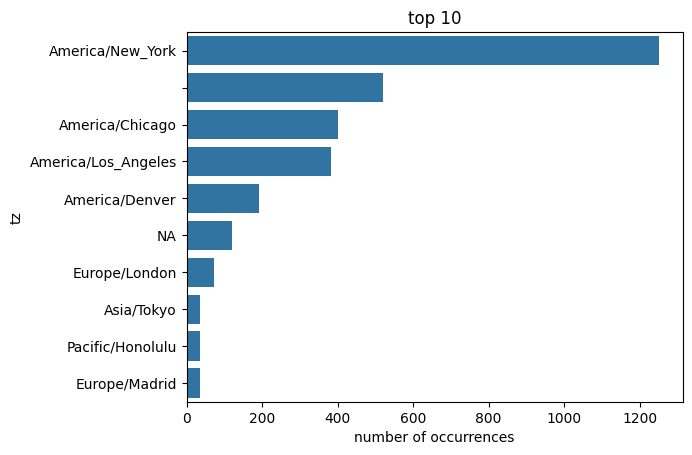

In [35]:
# visualization
ax=sns.barplot(y=tz_cts.index,x=tz_cts.to_numpy())
ax.set_title('top 10')
ax.set_xlabel('number of occurrences')

In [37]:
res=pd.Series([x.split()[0] for x in frame['a'].dropna()])
res.head(8)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
5               Mozilla/5.0
6               Mozilla/5.0
7               Mozilla/5.0
dtype: object

In [38]:
res.value_counts().head()

Mozilla/5.0               2594
Mozilla/4.0                601
GoogleMaps/RochesterNY     121
Opera/9.80                  34
TEST_INTERNET_AGENT         24
Name: count, dtype: int64

In [47]:
cframe=frame[frame['a'].notna()].copy()
cframe[['a']]

,a
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...
1,GoogleMaps/RochesterNY
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...
...,...
3555,Mozilla/4.0 (compatible; MSIE 9.0; Windows NT ...
3556,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/535.1...
3557,GoogleMaps/RochesterNY
3558,GoogleProducer


In [48]:
cframe['os']=np.where(cframe['a'].str.contains('Windows'),'Windows','Not Windows')
cframe.head()

,a,c,nk,tz,gr,g,h,l,al,hh,r,u,t,hc,cy,ll,_heartbeat_,kw,os
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,1.0,America/New_York,MA,A6qOVH,wfLQtf,orofrog,"en-US,en;q=0.8",1.usa.gov,http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/...,http://www.ncbi.nlm.nih.gov/pubmed/22415991,1.331923e+09,1.331823e+09,Danvers,"[42.576698, -70.954903]",NaN,NaN,Windows
1,GoogleMaps/RochesterNY,US,0.0,America/Denver,UT,mwszkS,mwszkS,bitly,NaN,j.mp,http://www.AwareMap.com/,http://www.monroecounty.gov/etc/911/rss.php,1.331923e+09,1.308262e+09,Provo,"[40.218102, -111.613297]",NaN,NaN,Not Windows
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,US,1.0,America/New_York,DC,xxr3Qb,xxr3Qb,bitly,en-US,1.usa.gov,http://t.co/03elZC4Q,http://boxer.senate.gov/en/press/releases/0316...,1.331923e+09,1.331920e+09,Washington,"[38.9007, -77.043098]",NaN,NaN,Windows
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,BR,0.0,America/Sao_Paulo,27,zCaLwp,zUtuOu,alelex88,pt-br,1.usa.gov,direct,http://apod.nasa.gov/apod/ap120312.html,1.331923e+09,1.331923e+09,Braz,"[-23.549999, -46.616699]",NaN,NaN,Not Windows
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,US,0.0,America/New_York,MA,9b6kNl,9b6kNl,bitly,"en-US,en;q=0.8",bit.ly,http://www.shrewsbury-ma.gov/selco/,http://www.shrewsbury-ma.gov/egov/gallery/1341...,1.331923e+09,1.273672e+09,Shrewsbury,"[42.286499, -71.714699]",NaN,NaN,Windows


In [49]:
by_tzos=cframe.groupby(['tz','os'])
by_tzos.size().unstack().fillna(0)

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0
...,...,...
Europe/Volgograd,0.0,1.0
Europe/Warsaw,1.0,15.0
Europe/Zurich,4.0,0.0


In [50]:
agg_count=by_tzos.size().unstack().fillna(0)
agg_count.sum(axis=1)

tz
                       521.0
Africa/Cairo             3.0
Africa/Casablanca        1.0
Africa/Ceuta             2.0
Africa/Johannesburg      1.0
                       ...  
Europe/Volgograd         1.0
Europe/Warsaw           16.0
Europe/Zurich            4.0
Pacific/Auckland        11.0
Pacific/Honolulu        36.0
Length: 97, dtype: float64

In [51]:
# index in order of sum
index=agg_count.sum(axis=1).argsort()
index.values[-10:]

array([35, 78, 96, 59, 77, 15, 22, 12,  0, 29])

In [54]:
agg=agg_count.take(index[-10:])
agg['total']=agg.sum(axis=1)
agg

os,Not Windows,Windows,total
tz,,,
America/Sao_Paulo,13.0,20.0,33.0
Europe/Madrid,16.0,19.0,35.0
Pacific/Honolulu,0.0,36.0,36.0
Asia/Tokyo,2.0,35.0,37.0
Europe/London,43.0,31.0,74.0
America/Denver,132.0,59.0,191.0
America/Los_Angeles,130.0,252.0,382.0
America/Chicago,115.0,285.0,400.0
,245.0,276.0,521.0


In [55]:
# get top 10 counts/sort().tail()
agg_count.sum(axis=1).nlargest()

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
dtype: float64

In [64]:
count_stack=agg.stack()
count_stack.name='total'
count_stack=count_stack.reset_index()
count_stack.head()

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,America/Sao_Paulo,total,33.0
3,Europe/Madrid,Not Windows,16.0
4,Europe/Madrid,Windows,19.0


<Axes: xlabel='total', ylabel='tz'>

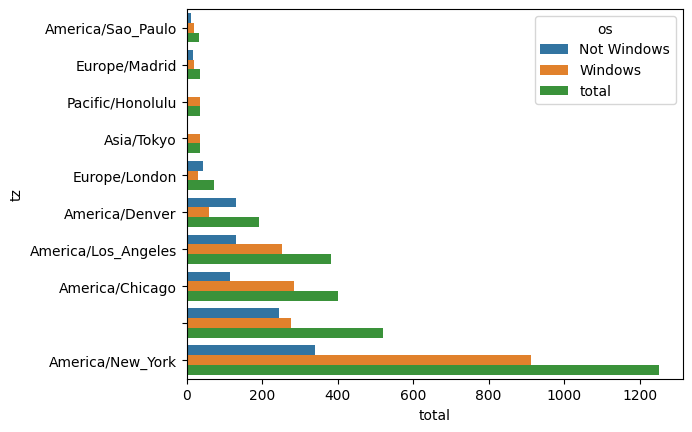

In [65]:
sns.barplot(x='total',y='tz',hue='os',data=count_stack)

In [69]:
def norm(group):
    group['norm']=group['total']/group['total'].sum()
    return group
#or
s=count_stack.groupby('tz')['total'].transform('sum')
res=count_stack.assign(norm=count_stack['total']/s)
res.head()

,tz,os,total,norm
0,America/Sao_Paulo,Not Windows,13.0,0.196970
1,America/Sao_Paulo,Windows,20.0,0.303030
2,America/Sao_Paulo,total,33.0,0.500000
3,Europe/Madrid,Not Windows,16.0,0.228571
4,Europe/Madrid,Windows,19.0,0.271429


<Axes: xlabel='norm', ylabel='tz'>

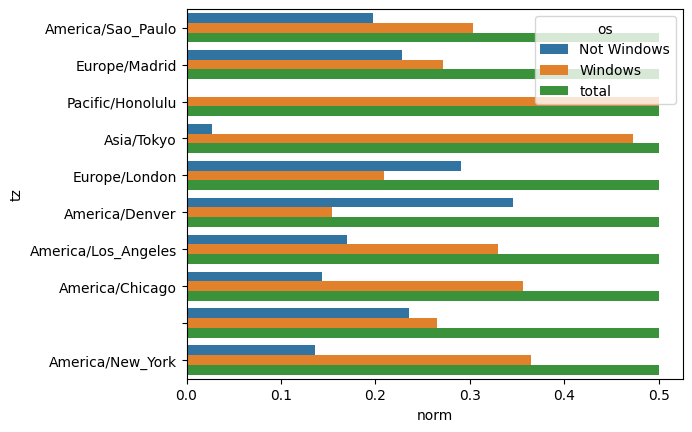

In [70]:
sns.barplot(x='norm',y='tz',hue='os',data=res)

# baby name

In [72]:
import pandas as pd
names2024=pd.read_csv('names/yob2024.txt',
                 names=['name','sex','num_births'])
names2024

,name,sex,num_births
0,Olivia,F,14718
1,Emma,F,13485
2,Amelia,F,12740
3,Charlotte,F,12552
4,Mia,F,12113
...,...,...,...
31899,Zylyn,M,5
31900,Zymiere,M,5
31901,Zypher,M,5
31902,Zyre,M,5


In [73]:
names2024.groupby('sex')['num_births'].sum()

sex
F    1613188
M    1715313
Name: num_births, dtype: int64

In [74]:
pieces=[]
for year in range(1880,2025):
    path=f'names/yob{year}.txt'
    frame=pd.read_csv(path,names=['name','sex','num_birth'])
    frame['year']=year
    pieces.append(frame)
names=pd.concat(pieces,ignore_index=True)
names

,name,sex,num_birth,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
2149472,Zylyn,M,5,2024
2149473,Zymiere,M,5,2024
2149474,Zypher,M,5,2024
2149475,Zyre,M,5,2024


In [75]:
total=names.pivot_table('num_birth',index='year',columns='sex',aggfunc='sum')
total

sex,F,M
year,,
1880,90994,110490
1881,91953,100735
1882,107847,113686
1883,112321,104625
1884,129019,114442
...,...,...
2020,1615512,1725065
2021,1639712,1748237
2022,1638762,1744373


<Axes: title={'center': 'total births by sex and year'}, xlabel='year'>

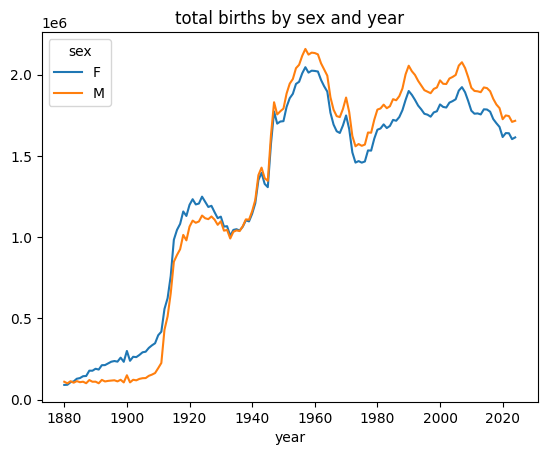

In [76]:
total.plot(title='total births by sex and year')

In [77]:
names['prop']=names.groupby(['year','sex'])['num_birth'].transform(lambda x: x/x.sum())

In [78]:
names

,name,sex,num_birth,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
2149472,Zylyn,M,5,2024,0.000003
2149473,Zymiere,M,5,2024,0.000003
2149474,Zypher,M,5,2024,0.000003
2149475,Zyre,M,5,2024,0.000003


In [79]:
names.groupby(['year','sex'])['prop'].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2022  M      1.0
2023  F      1.0
      M      1.0
2024  F      1.0
      M      1.0
Name: prop, Length: 290, dtype: float64

In [92]:
#top 100 names
top1=(
    names.sort_values(['year','sex','num_birth'],
                      ascending=[True,True,False])
    .groupby(['year','sex'],sort=False)
    .head(1000))
top1.head(1000)

,name,sex,num_birth,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
995,Ralph,M,317,1880,0.002869
996,Ed,M,310,1880,0.002806
997,Claude,M,309,1880,0.002797
998,Edwin,M,309,1880,0.002797


In [93]:
# when we reset the mutiple index, colnames will be like level_0.so we need to change
top1=top1.reset_index()
top1.rename(columns={'level_0':'year','level_1':'sex'},inplace=True)
if 'level2' in top1.columns:
    top1=top1.drop(columns=['level2'])
top1

,index,name,sex,num_birth,year,prop
0,0,Mary,F,7065,1880,0.077642
1,1,Anna,F,2604,1880,0.028617
2,2,Emma,F,2003,1880,0.022012
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...,...
289871,2136229,Vance,M,226,2024,0.000132
289872,2136230,Aden,M,225,2024,0.000131
289873,2136231,Ishaan,M,225,2024,0.000131
289874,2136232,Kace,M,225,2024,0.000131


In [94]:
# reset the index and drop the original one
top1=top1.reset_index(drop=True)
top1

,index,name,sex,num_birth,year,prop
0,0,Mary,F,7065,1880,0.077642
1,1,Anna,F,2604,1880,0.028617
2,2,Emma,F,2003,1880,0.022012
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...,...
289871,2136229,Vance,M,226,2024,0.000132
289872,2136230,Aden,M,225,2024,0.000131
289873,2136231,Ishaan,M,225,2024,0.000131
289874,2136232,Kace,M,225,2024,0.000131


In [95]:
boys=top1[top1['sex']=='M']
girls=top1[top1['sex']=='F']

In [96]:
total=top1.pivot_table('num_birth',index='year',columns='name',aggfunc='sum')
total

name,Aaden,Aadhya,Aaliyah,Aanya,Aarav,Aarna,Aaron,Aarush,Aarya,Aayan,...,Zona,Zora,Zoya,Zula,Zuri,Zyair,Zyaire,Zyla,Zymir,Zyon
year,,,,,,,,,,,,,,,,,,,,,
1880,NaN,NaN,NaN,NaN,NaN,NaN,102.0,NaN,NaN,NaN,...,8.0,28.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1881,NaN,NaN,NaN,NaN,NaN,NaN,94.0,NaN,NaN,NaN,...,9.0,21.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1882,NaN,NaN,NaN,NaN,NaN,NaN,85.0,NaN,NaN,NaN,...,17.0,32.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN
1883,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,NaN,...,11.0,35.0,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN
1884,NaN,NaN,NaN,NaN,NaN,NaN,97.0,NaN,NaN,NaN,...,8.0,58.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,NaN,NaN,3578.0,NaN,419.0,NaN,5098.0,NaN,256.0,NaN,...,NaN,308.0,282.0,NaN,1268.0,226.0,672.0,NaN,NaN,NaN
2021,NaN,NaN,3613.0,NaN,431.0,268.0,4851.0,NaN,NaN,NaN,...,NaN,338.0,267.0,NaN,1440.0,324.0,835.0,NaN,NaN,242.0
2022,NaN,268.0,3284.0,NaN,406.0,NaN,4524.0,NaN,NaN,NaN,...,NaN,332.0,358.0,NaN,1520.0,354.0,871.0,NaN,NaN,277.0


<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 1880 to 2024
Columns: 7386 entries, Aaden to Zyon
dtypes: float64(7386)
memory usage: 8.2 MB


array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>], dtype=object)

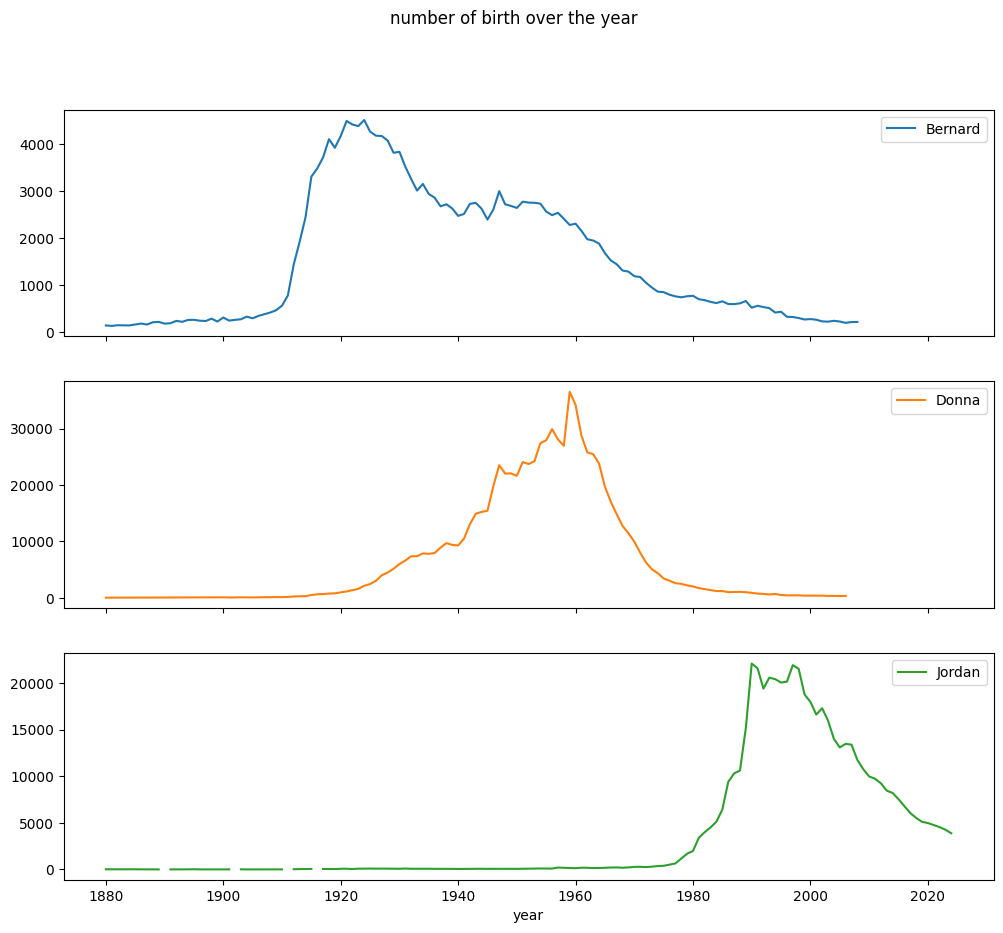

In [97]:
total.info()
subset=total[['Bernard','Donna','Jordan']]
subset.plot(subplots=True,figsize=(12,10),title='number of birth over the year')

<Axes: title={'center': 'sum of top1 names proportion by year and sex'}, xlabel='year'>

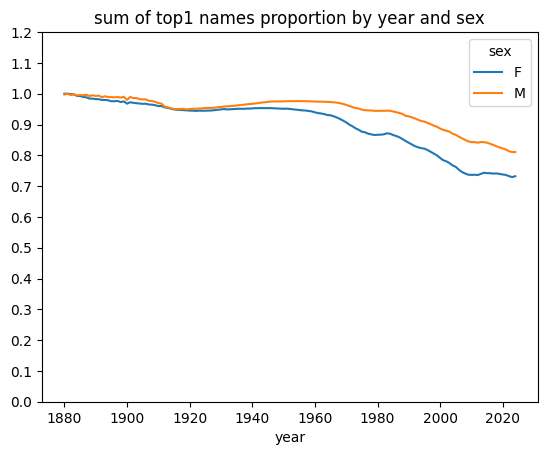

In [98]:
import numpy as np
tab=top1.pivot_table('prop',index='year',columns='sex',aggfunc='sum')
tab.plot(title='sum of top1 names proportion by year and sex',
         yticks=np.linspace(0,1.2,13))

In [99]:
all_names=pd.Series(top1['name'].unique())
les=all_names[all_names.str.contains('Les')]
print(les)

395     Lessie
654     Leslie
1030    Lester
2100      Less
2306    Lesley
2376     Lesta
4211       Les
4257    Leslee
4448      Lesa
4628     Lesia
4725     Lesli
6095     Lesly
dtype: object


In [100]:
filtered=top1[top1['name'].isin(les)]
print(filtered.groupby('name')['num_birth'].sum())

name
Les         2034
Lesa        9896
Lesia       2216
Leslee      1083
Lesley     34986
Lesli        929
Leslie    381122
Lesly      11434
Less          28
Lessie     12886
Lesta         17
Lester    127569
Name: num_birth, dtype: int64


In [101]:
tab=filtered.pivot_table('num_birth',index='year',columns='sex',aggfunc='sum')
tab

sex,F,M
year,,
1880,26.0,188.0
1881,29.0,184.0
1882,34.0,262.0
1883,46.0,246.0
1884,60.0,248.0
...,...,...
2020,488.0,NaN
2021,477.0,NaN
2022,453.0,NaN


In [102]:
#normalization with year
tab=tab.div(tab.sum(axis=1),axis='index')
tab

sex,F,M
year,,
1880,0.121495,0.878505
1881,0.136150,0.863850
1882,0.114865,0.885135
1883,0.157534,0.842466
1884,0.194805,0.805195
...,...,...
2020,1.000000,NaN
2021,1.000000,NaN
2022,1.000000,NaN


<Axes: title={'center': 'Proportion of "lesley" breakdown by year and sex'}, xlabel='year'>

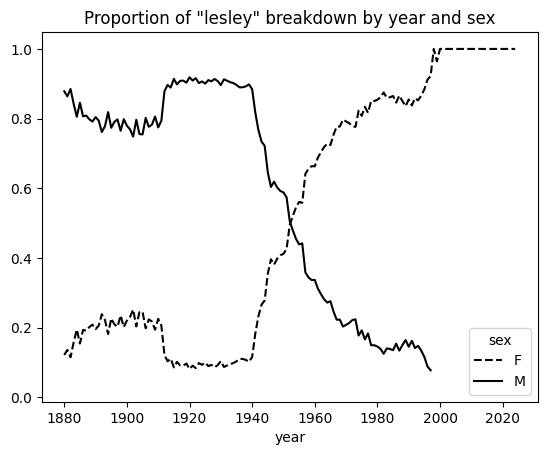

In [103]:
tab.plot(style={'M':'k-','F':'k--'},title='Proportion of "lesley" breakdown by year and sex')

#sum of missing

isna().sum()

#fill the missing

fillna()

#split the continue data and include the left boundary only

pd.cut(x,bins=[1,2,3,,,],labels=[a,b,c,,,],right=False)

#convert the type

.astype(int)

#convert into a object which could recognized by numpy

.to_numpy()

#logistic regression

from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(x,y)

model.predict(x_test)

#if you worry about overfitting, we could use LogiaticRegression() model